<a href="https://colab.research.google.com/github/Saisohangoud/AI-Job-Market-Analyzer/blob/main/AI_Job_Market_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I wanted to look at the AI job postings dataset and see which roles pay the most, which countries are hiring the most AI talent, and wheather I could build a quick model to predict salary from just job title and location

    job_id                 job_title  salary_usd salary_currency  \
0  AI00001            Data Scientist      219728             USD   
1  AI00002                Head of AI      230237             JPY   
2  AI00003             Data Engineer      128890             EUR   
3  AI00004  Computer Vision Engineer       96349             USD   
4  AI00005         Robotics Engineer       63065             EUR   

   salary_local experience_level employment_type company_location  \
0        219728               EX              PT           Sweden   
1      25326070               EX              PT            Japan   
2        109557               EX              CT          Germany   
3         96349               MI              FL          Finland   
4         53605               EN              FT           France   

  company_size employee_residence  remote_ratio  \
0            M             Sweden             0   
1            L              Japan            50   
2            S         

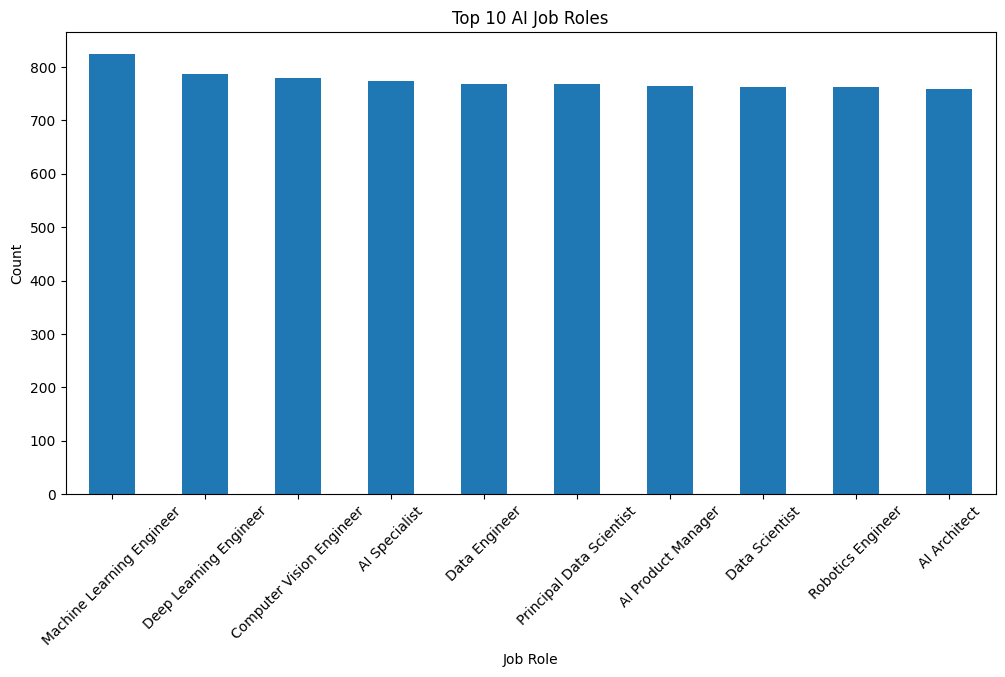

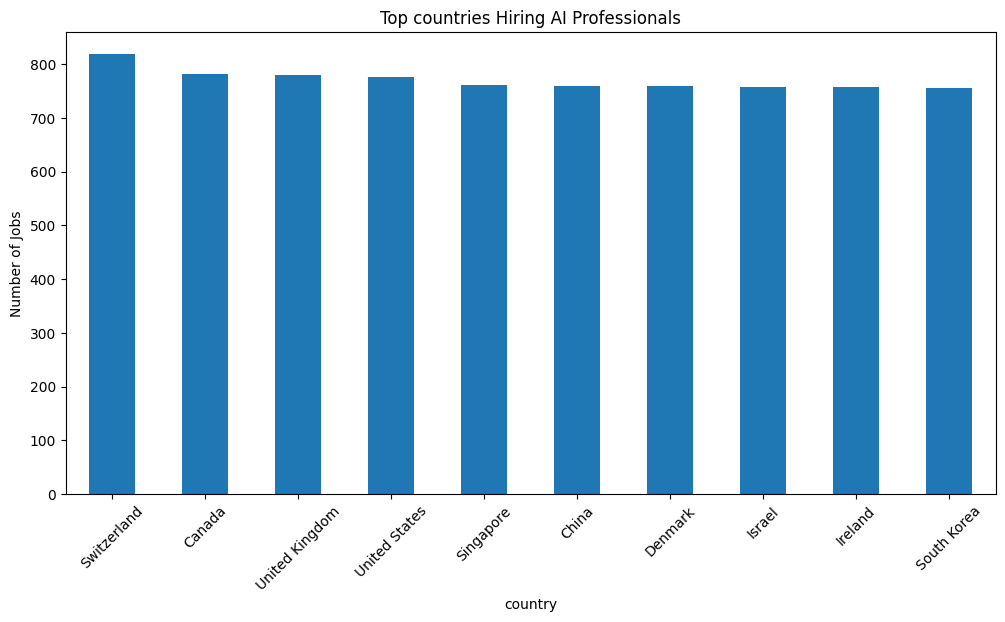

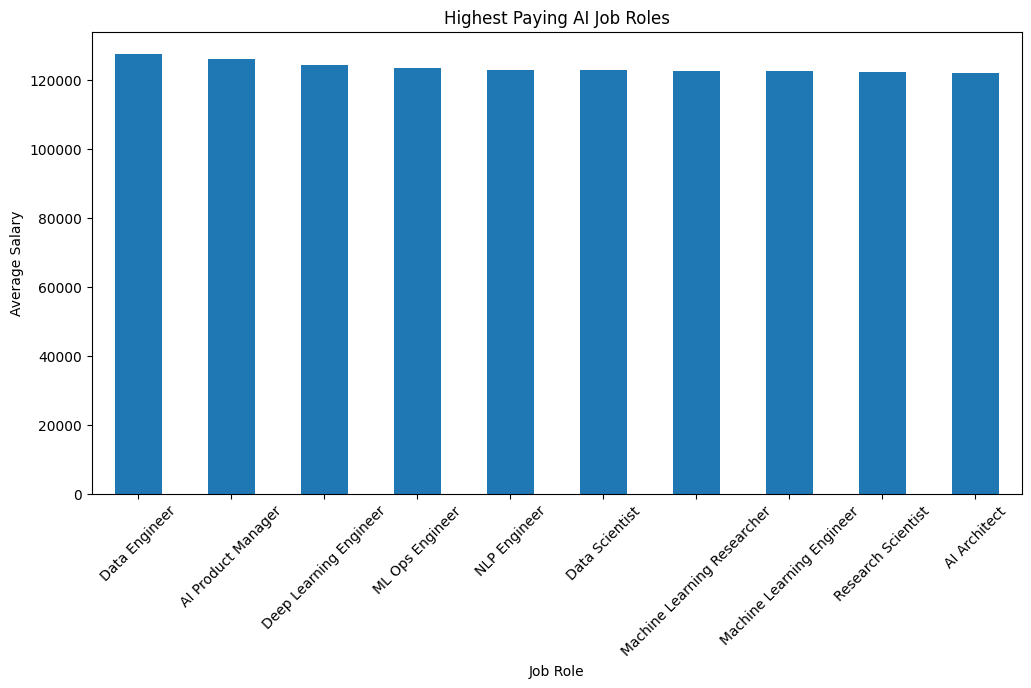


MODEL TRAINED SUCCESSFULLY!

MODEL PERFORMANCE:
Mean Absolute Error: 44844.00802876061
R2 Score: 0.19174695041820822
predicted salary: $145,335.61


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


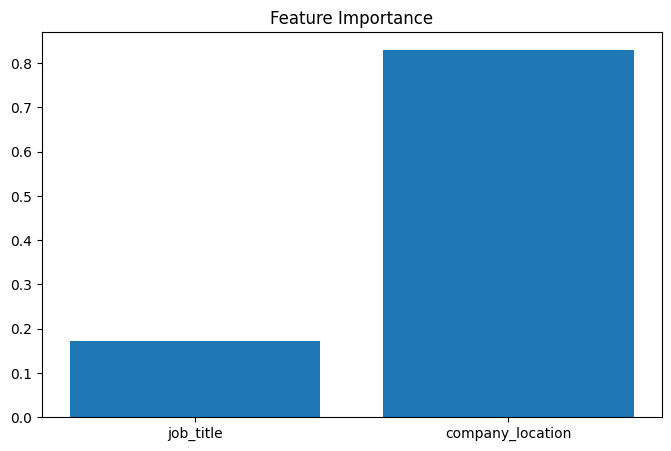

Model saved.

AI JOB MARKET ANALYZER PROJECT COMPLETED SUCCESSFULLY!


In [3]:
# AI JOB MARKET ANALYZER PROJECT

!pip install pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Loading the data

# Uploaded the csv to Colab's/content folder first.
# Renaming the file path below if yours is different.

df = pd.read_csv('/content/ai_job_dataset.csv')

print(df.head())

print(df.shape)

print(df.columns)

# Checking for missing values
# Getting a feel for the numeric columns before i start cleaning anything

print(df.info())

print(df.isnull().sum())

print(df.describe())

# didn't actually find any nulls in this dataset but keeping this in
# just in case the file chnages later

df = df.dropna()

# A few quick visualizations

plt.figure(figsize=(12,6))
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 AI Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# curious which countries show up most in the postings

plt.figure(figsize=(12,6))
df['company_location'].value_counts().head(10).plot(kind='bar')
plt.title('Top countries Hiring AI Professionals')
plt.xlabel('country')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

# Average salary by job role

avg_salary = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
avg_salary.plot(kind='bar')
plt.title('Highest Paying AI Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.show()

# Building a simple salary prediction model
# just using job title and company location as features to start
# could add more later (years of experiance, remote raio etc probably matter too but keeping this simple for now)

le_job = LabelEncoder()
le_country = LabelEncoder()

df['job_title'] = le_job.fit_transform(df['job_title'])
df['company_location'] = le_country.fit_transform(df['company_location'])

X = df[['job_title', 'company_location']]
y = df['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY!")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# r2 isn't great with just these two features, might revist with more columns later


# Example:
# Data Scientist in USA

sample_job = le_job.transform(['Data Scientist'])[0]
sample_country = le_country.transform(['United States'])[0]

sample_input = [[sample_job, sample_country]]
predicted_salary = model.predict(sample_input)

print(f"predicted salary: ${predicted_salary[0]:,.2f}")


importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.bar(feature_names, importance)
plt.title('Feature Importance')
plt.show()

# Saving the model so I don't have to retrain it every time

import joblib

joblib.dump(model, 'salary_prediction_model.pkl')
print("Model saved.")

print("\nAI JOB MARKET ANALYZER PROJECT COMPLETED SUCCESSFULLY!")